In [1]:
# Setup
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# GPU memory config
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

print(f"TensorFlow version: {tf.__version__}")
print("GPU Available:", tf.config.list_physical_devices('GPU'))

np.random.seed(42)
tf.random.set_seed(42)

# Constants
LATENT_DIM = 8
KL_WEIGHT = 16.0
BATCH_SIZE = 256
LEARNING_RATE = 0.001
CLIPNORM = 2.0

2026-03-09 23:45:16.963098: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-09 23:45:17.027119: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-09 23:45:18.255212: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Sampling Layer
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = keras.random.normal(shape=keras.ops.shape(z_mean), dtype=z_mean.dtype)
        return z_mean + keras.ops.exp(0.5 * z_log_var) * epsilon

# Encoder
def build_encoder(latent_dim=LATENT_DIM):
    inputs = keras.Input(shape=(32, 32, 1))
   
    x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    
    x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    
    x = layers.Conv2D(128, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    
    x = layers.Flatten()(x)
    
    z_mean    = layers.Dense(latent_dim, name='z_mean')(x)
    z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)
    z         = Sampling()([z_mean, z_log_var])
    
    return keras.Model(inputs, [z_mean, z_log_var, z], name='encoder')

# Decoder
def build_decoder(latent_dim=LATENT_DIM):
    inputs = keras.Input(shape=(latent_dim,))
    
    x = layers.Dense(4 * 4 * 128, activation='relu')(inputs)
    x = layers.Reshape((4, 4, 128))(x)
    
    x = layers.Conv2DTranspose(128, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
   
    x = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    
    x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    
    outputs = layers.Conv2D(1, 3, padding='same', activation='sigmoid', dtype='float32')(x)
    
    return keras.Model(inputs, outputs, name='decoder')

# VAE
class VAE(keras.Model):
    def __init__(self, encoder, decoder, kl_weight, **kwargs):
        super().__init__(**kwargs)
        self.encoder   = encoder
        self.decoder   = decoder
        self.kl_weight = kl_weight

    def call(self, x):
        z_mean, z_log_var, z = self.encoder(x)
        return self.decoder(z)

    def _compute_losses(self, x, reconstruction, z_mean, z_log_var):
        image_size = tf.cast(tf.reduce_prod(tf.shape(x)[1:3]), tf.float32)
        recon_loss = tf.reduce_mean(
            keras.losses.binary_crossentropy(x, reconstruction)
        ) * image_size
        kl_loss = -0.5 * tf.reduce_mean(
            z_log_var - tf.square(z_mean) - tf.exp(z_log_var) + 1
        )
        total_loss = recon_loss + self.kl_weight * kl_loss
        return {"loss": total_loss, "recon_loss": recon_loss, "kl_loss": kl_loss}

    def train_step(self, data):
        x, _ = data
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(x, training=True)
            reconstruction       = self.decoder(z, training=True)
            losses               = self._compute_losses(x, reconstruction, z_mean, z_log_var)
        grads = tape.gradient(losses["loss"], self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return losses

    def test_step(self, data):
        x, _ = data
        z_mean, z_log_var, z = self.encoder(x, training=False)
        reconstruction       = self.decoder(z, training=False)
        return self._compute_losses(x, reconstruction, z_mean, z_log_var)

encoder = build_encoder(latent_dim=LATENT_DIM)
decoder = build_decoder(latent_dim=LATENT_DIM)
vae     = VAE(encoder, decoder, kl_weight=KL_WEIGHT, name='vae')
vae.compile(optimizer=keras.optimizers.Adam(
    learning_rate=LEARNING_RATE,
    clipnorm=CLIPNORM
))
print("VAE built successfully")

I0000 00:00:1773099919.138364  193627 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


VAE built successfully


In [3]:
# Load MNIST
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

x_train = np.pad(x_train, ((0,0), (2,2), (2,2)), mode='constant')
x_test  = np.pad(x_test,  ((0,0), (2,2), (2,2)), mode='constant')

x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test,  -1)

print(f"Training data: {x_train.shape}")
print(f"Test data:     {x_test.shape}")

# tf.data pipeline
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, x_train))
train_dataset = train_dataset.shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset   = tf.data.Dataset.from_tensor_slices((x_test, x_test))
val_dataset   = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Callbacks
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)
lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.75, patience=5, min_lr=1e-6
)

history = vae.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=[early_stopping, lr_scheduler]
)

Training data: (60000, 32, 32, 1)
Test data:     (10000, 32, 32, 1)
Epoch 1/50


2026-03-09 23:45:25.789728: I external/local_xla/xla/service/service.cc:163] XLA service 0x7c4d9801f660 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-09 23:45:25.789775: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-03-09 23:45:25.908475: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-09 23:45:26.966287: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


  8/235 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - kl_loss: 4.5130 - loss: 802.0682 - recon_loss: 729.8599 

I0000 00:00:1773099934.429939  193708 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


235/235 ━━━━━━━━━━━━━━━━━━━━ 25s 55ms/step - kl_loss: 1.5591 - loss: 137.9023 - recon_loss: 112.9560 - val_kl_loss: 0.9152 - val_loss: 517.9070 - val_recon_loss: 503.2633 - learning_rate: 0.0010
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - kl_loss: 1.5244 - loss: 137.2965 - recon_loss: 112.9064 - val_kl_loss: 1.2359 - val_loss: 223.7372 - val_recon_loss: 203.9625 - learning_rate: 0.0010
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - kl_loss: 1.5599 - loss: 129.5203 - recon_loss: 104.5620 - val_kl_loss: 1.5868 - val_loss: 128.6486 - val_recon_loss: 103.2602 - learning_rate: 0.0010
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - kl_loss: 1.5966 - loss: 129.6502 - recon_loss: 104.1045 - val_kl_loss: 1.7234 - val_loss: 123.4789 - val_recon_loss: 95.9052 - learning_rate: 0.0010
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - kl_loss: 1.6732 - loss: 124.2308 - recon_loss: 97.4600 - val_kl_loss: 1.7258 - val_loss: 118.0904 - val_recon_loss: 90.4780 - learning_r

/tmp/ipykernel_193627/926766759.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


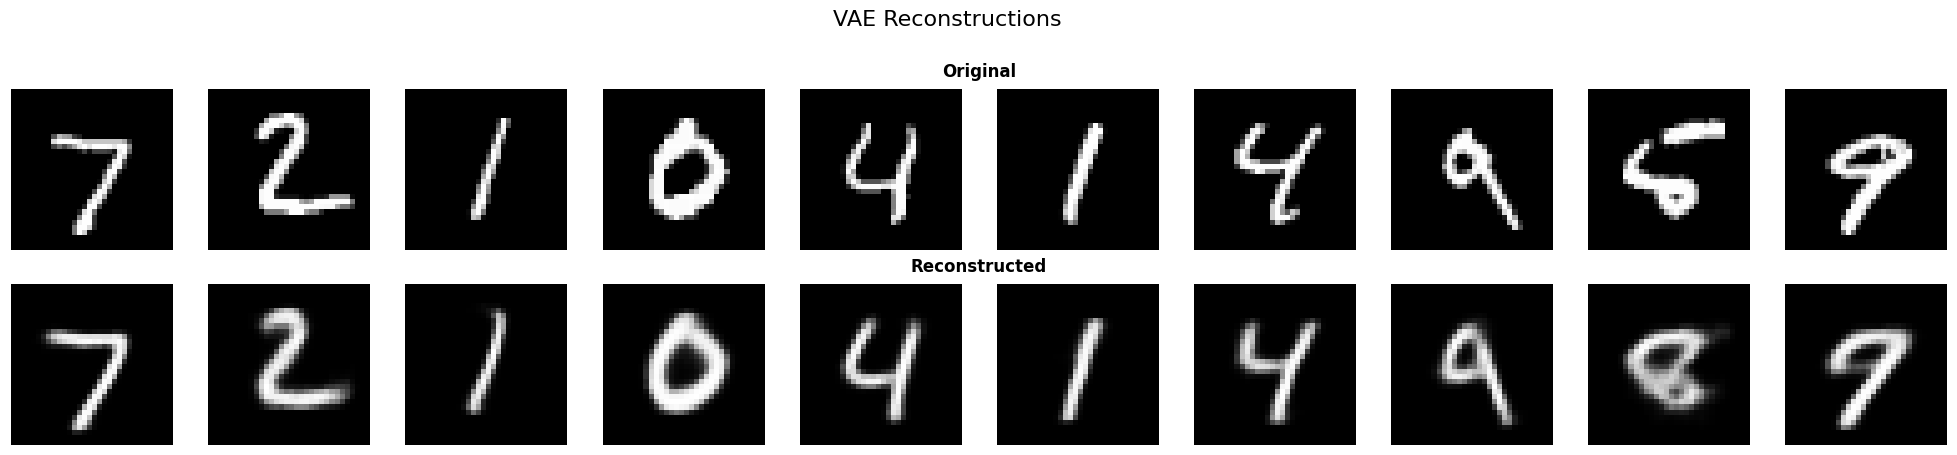

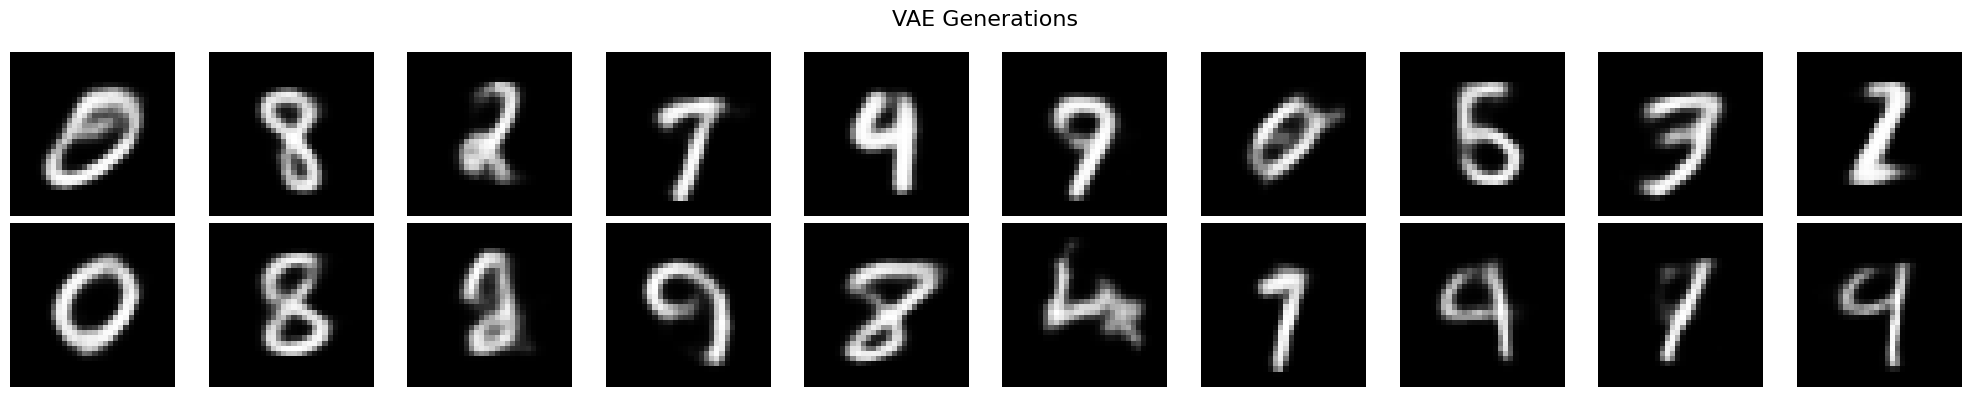

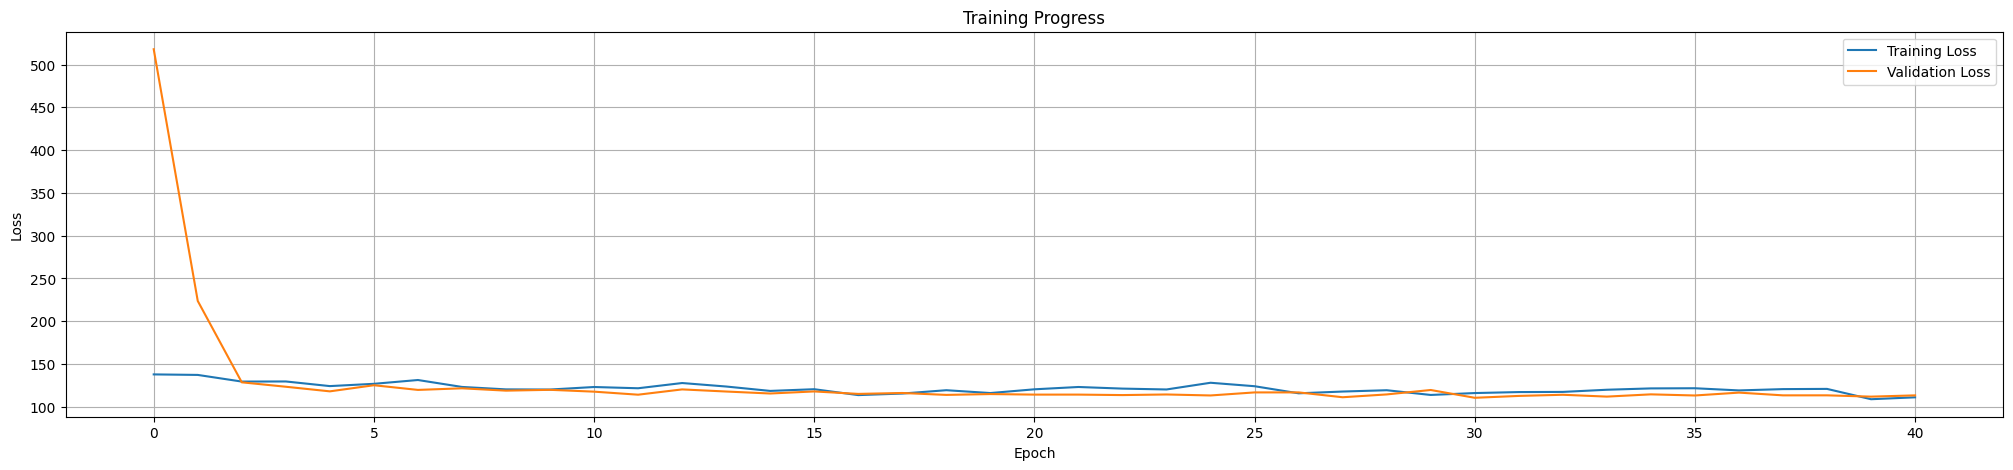

Final training loss:   111.1180
Final validation loss: 113.3943


In [4]:
# Reconstruct 10 test images
test_samples  = x_test[:10]
reconstructed = vae.predict(test_samples, verbose=0)

# Show originals vs reconstructions
fig = plt.figure(figsize=(25, 5))
gs = fig.add_gridspec(4, 10, height_ratios=[0.15, 1, 0.15, 1], hspace=0.05)

# Label rows
for label, row in [('Original', 0), ('Reconstructed', 2)]:
    ax = fig.add_subplot(gs[row, :])
    ax.text(0.5, 0.5, label, ha='center', va='center', fontsize=12, fontweight='bold')
    ax.axis('off')

# Image rows
for i in range(10):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(test_samples[i], cmap='gray')
    ax.axis('off')

    ax = fig.add_subplot(gs[3, i])
    ax.imshow(np.clip(reconstructed[i], 0, 1), cmap='gray')
    ax.axis('off')

plt.suptitle('VAE Reconstructions', fontsize=16)
plt.tight_layout()
plt.show()

# Generate 20 new images
n_samples = 20
random_latent = np.random.normal(size=(n_samples, LATENT_DIM))
generated = decoder.predict(random_latent, verbose=0)

fig, axes = plt.subplots(2, 10, figsize=(20, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(np.clip(generated[i], 0, 1), cmap='gray')
    ax.axis('off')

plt.suptitle('VAE Generations', fontsize=16)
plt.tight_layout()
plt.show()

# Training loss curve
plt.figure(figsize=(25, 5))
plt.plot(history.history['loss'],     label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Progress')
plt.legend()
plt.grid(True)
plt.show()

print(f"Final training loss:   {history.history['loss'][-1]:.4f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.4f}")